In [6]:
%pip install pandas numpy scikit-learn pyarrow matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import joblib

print("Python environment ready")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python environment ready
Pandas: 3.0.5
NumPy: 2.5.2


In [8]:
file_path = Path.home() / "Documents" / "NASA_PHA_Project" / "Asteroiddataset.csv"

print("File:", file_path)
print("Exists:", file_path.exists())

File: /Users/hrushikeshdunde/Documents/NASA_PHA_Project/Asteroiddataset.csv
Exists: True


In [9]:
asteroid_data = pd.read_csv(file_path)

print("Dataset shape:", asteroid_data.shape)


Dataset shape: (1548691, 19)


In [10]:
asteroid_data.head()

,spkid,full_name,neo,pha,H,diameter,albedo,e,a,q,i,n,per_y,moid,moid_ld,class,data_arc,condition_code,rms
0,20000001,1 Ceres (A801 AA),N,N,3.34,939.400,0.0900,0.0797,2.766,2.545,10.59,0.2143,4.60,1.58,615.0,MBA,9520.0,0.0,0.43153
1,20000002,2 Pallas (A802 FA),N,N,4.12,513.000,0.1550,0.2307,2.770,2.131,34.93,0.2138,4.61,1.23,477.0,MBA,80828.0,0.0,0.35838
2,20000003,3 Juno (A804 RA),N,N,5.19,246.596,0.2140,0.2557,2.671,1.988,12.99,0.2258,4.37,1.04,404.0,MBA,80897.0,0.0,0.35631
3,20000004,4 Vesta (A807 FA),N,N,3.25,522.770,0.4228,0.0902,2.361,2.148,7.14,0.2716,3.63,1.14,442.0,MBA,25743.0,0.0,0.40095
4,20000005,5 Astraea (A845 XA),N,N,6.95,106.699,0.2740,0.1876,2.577,2.093,5.36,0.2383,4.14,1.11,431.0,MBA,65687.0,0.0,0.47883


In [11]:
asteroid_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548691 entries, 0 to 1548690
Data columns (total 19 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   spkid           1548691 non-null  int64  
 1   full_name       1548691 non-null  str    
 2   neo             1548686 non-null  str    
 3   pha             1519613 non-null  str    
 4   H               1548185 non-null  float64
 5   diameter        139582 non-null   float64
 6   albedo          138461 non-null   float64
 7   e               1548691 non-null  float64
 8   a               1548691 non-null  float64
 9   q               1548691 non-null  float64
 10  i               1548691 non-null  float64
 11  n               1548691 non-null  float64
 12  per_y           1548686 non-null  float64
 13  moid            1519613 non-null  float64
 14  moid_ld         1519613 non-null  float64
 15  class           1548691 non-null  str    
 16  data_arc        1546637 non-null  float64
 17  

In [12]:
asteroid_data.describe(include="all")

,spkid,full_name,neo,pha,H,diameter,albedo,e,a,q,i,n,per_y,moid,moid_ld,class,data_arc,condition_code,rms
count,1.548691e+06,1548691,1548686,1519613,1.548185e+06,139582.000000,138461.000000,1.548691e+06,1.548691e+06,1.548691e+06,1.548691e+06,1.548691e+06,1.548686e+06,1.519613e+06,1.519613e+06,1548691,1.546637e+06,1.548668e+06,1.548689e+06
unique,NaN,1548691,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,NaN,NaN,NaN
top,NaN,1 Ceres (A801 AA),N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MBA,NaN,NaN,NaN
freq,NaN,1,1506869,1517073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1371109,NaN,NaN,NaN
mean,3.441296e+07,NaN,NaN,NaN,1.764209e+01,5.459700,0.130116,1.587230e-01,2.927221e+00,2.415901e+00,9.306291e+00,2.350929e-01,9.096914e+00,1.433026e+00,5.576930e+02,NaN,6.353034e+03,1.197289e+00,5.267911e-01
std,1.639010e+07,NaN,NaN,NaN,1.907681e+00,9.307543,0.110372,9.484334e-02,2.179709e+01,2.215923e+00,6.657445e+00,8.448567e-02,1.951178e+03,2.229217e+00,8.675337e+02,NaN,4.230815e+03,2.502313e+00,1.458060e-01
min,2.000000e+07,NaN,NaN,NaN,-1.260000e+00,0.002500,0.001000,0.000000e+00,-1.568000e+04,6.900000e-02,1.000000e-02,5.022000e-07,3.140000e-01,4.540000e-07,1.770000e-04,NaN,0.000000e+00,0.000000e+00,2.408400e-06
25%,2.038717e+07,NaN,NaN,NaN,1.672000e+01,2.764000,0.053000,9.270000e-02,2.400000e+00,1.973000e+00,4.370000e+00,1.870000e-01,3.720000e+00,9.800000e-01,3.810000e+02,NaN,3.827000e+03,0.000000e+00,4.911100e-01
50%,2.077435e+07,NaN,NaN,NaN,1.764000e+01,3.950000,0.078000,1.474000e-01,2.668000e+00,2.245000e+00,7.890000e+00,2.261000e-01,4.360000e+00,1.260000e+00,4.890000e+02,NaN,6.621000e+03,0.000000e+00,5.424400e-01
75%,5.420781e+07,NaN,NaN,NaN,1.854000e+01,5.732000,0.189000,2.043000e-01,3.029000e+00,2.595000e+00,1.268000e+01,2.651000e-01,5.270000e+00,1.610000e+00,6.250000e+02,NaN,8.734000e+03,1.000000e+00,5.945300e-01


In [13]:
print("Number of rows:", asteroid_data.shape[0])
print("Number of columns:", asteroid_data.shape[1])

Number of rows: 1548691
Number of columns: 19


In [14]:
print(asteroid_data.columns.tolist())

['spkid', 'full_name', 'neo', 'pha', 'H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'n', 'per_y', 'moid', 'moid_ld', 'class', 'data_arc', 'condition_code', 'rms']


In [261]:
# ============================================
# CHECK FOR DUPLICATE ASTEROID IDENTIFIERS
# ============================================

print("Total rows:", len(asteroid_data))
print("Unique spkid:", asteroid_data["spkid"].nunique())
print("Duplicate spkid records:", asteroid_data["spkid"].duplicated().sum())

# Show duplicated asteroid IDs
duplicate_ids = asteroid_data[
    asteroid_data["spkid"].duplicated(keep=False)
].sort_values("spkid")

print("\nDuplicated asteroid records:")
display(duplicate_ids)

Total rows: 1548691
Unique spkid: 1548691
Duplicate spkid records: 0

Duplicated asteroid records:


,spkid,full_name,neo,pha,H,diameter,albedo,e,a,q,i,n,per_y,moid,moid_ld,class,data_arc,condition_code,rms


In [15]:
imputation_columns = [
    "H",
    "diameter",
    "albedo",
    "e",
    "a",
    "q",
    "i",
    "n",
    "per_y",
    "moid",
    "moid_ld",
    "class",
    "data_arc",
    "condition_code",
    "rms",
    "neo",
    "pha"
]

imputation_data = asteroid_data[imputation_columns].copy()

print("Imputation dataset shape:", imputation_data.shape)

Imputation dataset shape: (1548691, 17)


In [19]:
missing_count = imputation_data.isna().sum()

print("Missing values by variable:")
print(missing_count)

Missing values by variable:
H                     506
diameter          1409109
albedo            1410230
e                       0
a                       0
q                       0
i                       0
n                       0
per_y                   5
moid                29078
moid_ld             29078
class                   0
data_arc             2054
condition_code         23
rms                     2
neo                     5
pha                 29078
dtype: int64


In [20]:
missing_percentage = (
    imputation_data.isna().mean() * 100
).sort_values(ascending=False)

print("Missing percentage by variable:")
print(missing_percentage)

Missing percentage by variable:
albedo            91.059482
diameter          90.987098
pha                1.877586
moid_ld            1.877586
moid               1.877586
data_arc           0.132628
H                  0.032673
condition_code     0.001485
neo                0.000323
per_y              0.000323
rms                0.000129
n                  0.000000
i                  0.000000
q                  0.000000
a                  0.000000
class              0.000000
e                  0.000000
dtype: float64


In [21]:
missing_summary = pd.DataFrame({
    "Missing_Count": imputation_data.isna().sum(),
    "Missing_Percentage": imputation_data.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

print(missing_summary)

                Missing_Count  Missing_Percentage
albedo                1410230           91.059482
diameter              1409109           90.987098
pha                     29078            1.877586
moid_ld                 29078            1.877586
moid                    29078            1.877586
data_arc                 2054            0.132628
H                         506            0.032673
condition_code             23            0.001485
neo                         5            0.000323
per_y                       5            0.000323
rms                         2            0.000129
n                           0            0.000000
i                           0            0.000000
q                           0            0.000000
a                           0            0.000000
class                       0            0.000000
e                           0            0.000000


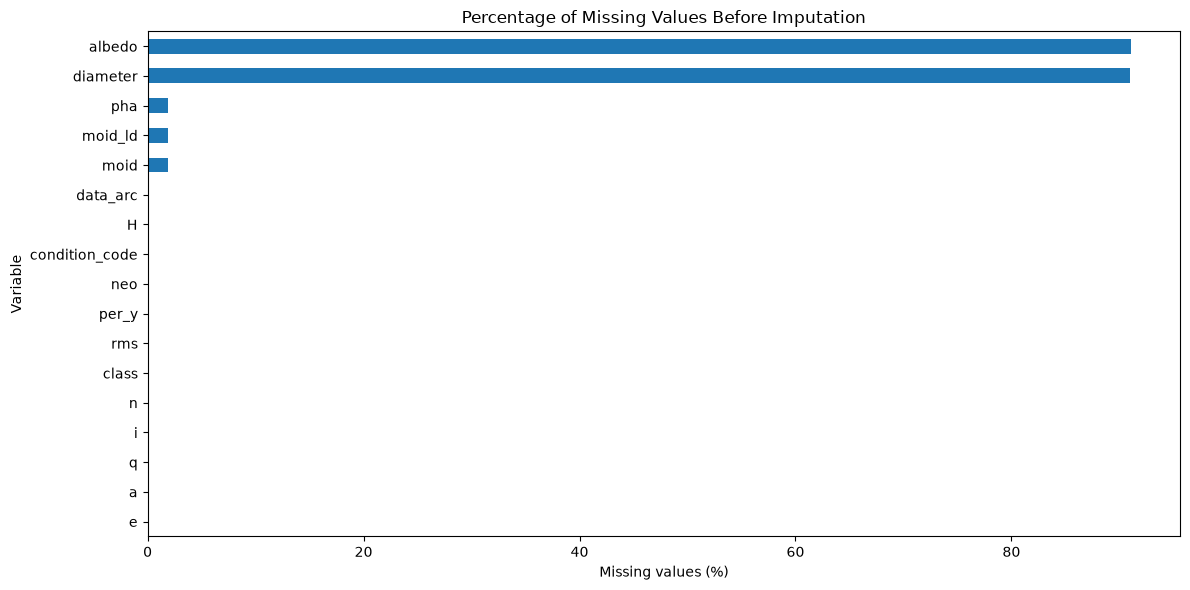

In [22]:
plt.figure(figsize=(12, 6))

missing_percentage.sort_values(ascending=True).plot(
    kind="barh"
)

plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Percentage of Missing Values Before Imputation")

plt.tight_layout()
plt.show()

In [23]:
Path("data").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

print("Current folder:", Path.cwd())
print("Data folder:", Path("data").resolve())
print("Models folder:", Path("models").resolve())
print("Results folder:", Path("results").resolve())

Current folder: /Users/hrushikeshdunde/Documents/NASA_PHA_Project
Data folder: /Users/hrushikeshdunde/Documents/NASA_PHA_Project/data
Models folder: /Users/hrushikeshdunde/Documents/NASA_PHA_Project/models
Results folder: /Users/hrushikeshdunde/Documents/NASA_PHA_Project/results


In [31]:
imputation_columns = [
    "H",
    "diameter",
    "albedo",
    "e",
    "a",
    "q",
    "i",
    "n",
    "per_y",
    "moid",
    "moid_ld",
    "class",
    "data_arc",
    "condition_code",
    "rms",
    "neo",
    "pha"
]

imputation_data = asteroid_data[imputation_columns].copy()

print("Imputation dataset shape:", imputation_data.shape)

Imputation dataset shape: (1548691, 17)


In [32]:
variables_to_impute = [
    col for col in imputation_data.columns
    if imputation_data[col].isna().any()
]

print("Variables requiring imputation:")
print(variables_to_impute)

Variables requiring imputation:
['H', 'diameter', 'albedo', 'per_y', 'moid', 'moid_ld', 'data_arc', 'condition_code', 'rms', 'neo', 'pha']


In [43]:
def iterative_pmm_random_forest(
    data,
    target_columns,
    n_trees=50,
    pmm_k=5,
    max_iter=5,
    random_state=123
):
    """
    Iterative Random Forest + Predictive Mean Matching.

    Numeric variables are imputed using Random Forest regression
    followed by Predictive Mean Matching (PMM).

    pha and neo are excluded from predictors to avoid target leakage
    and categorical-variable errors.
    """

    # ---------------------------------------------------------
    # Copy data
    # ---------------------------------------------------------
    df = data.copy()

    rng = np.random.default_rng(random_state)

    # ---------------------------------------------------------
    # Safety: remove pha and neo from imputation targets
    # ---------------------------------------------------------
    target_columns = [
        col for col in target_columns
        if col not in ["pha", "neo"]
    ]

    print("Variables to impute:")
    print(target_columns)

    # ---------------------------------------------------------
    # Check that target columns exist
    # ---------------------------------------------------------
    missing_columns = [
        col for col in target_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"These target columns do not exist: "
            f"{missing_columns}"
        )

    # ---------------------------------------------------------
    # Numeric columns only
    # ---------------------------------------------------------
    numeric_columns = df.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    # NEVER use outcome or categorical N/Y variables
    # as predictors
    excluded_predictors = ["pha", "neo"]

    numeric_predictors = [
        col for col in numeric_columns
        if col not in excluded_predictors
    ]

    print("\nNumeric predictor variables:")
    print(numeric_predictors)

    # ---------------------------------------------------------
    # Iterative PMM
    # ---------------------------------------------------------
    for iteration in range(max_iter):

        print("\n" + "=" * 70)
        print(
            f"IMPUTATION ITERATION "
            f"{iteration + 1}/{max_iter}"
        )
        print("=" * 70)

        total_remaining = 0

        # -----------------------------------------------------
        # Process each target
        # -----------------------------------------------------
        for target in target_columns:

            missing_mask = df[target].isna()

            n_missing = int(missing_mask.sum())

            # Nothing to impute
            if n_missing == 0:
                print(
                    f"\n{target}: already complete"
                )
                continue

            print(
                f"\nImputing {target} "
                f"({n_missing:,} missing)"
            )

            # -------------------------------------------------
            # Predictors
            # -------------------------------------------------
            predictors = [
                col
                for col in numeric_predictors
                if col != target
            ]

            # Keep predictors with at least some data
            predictors = [
                col
                for col in predictors
                if df[col].notna().sum() > 0
            ]

            if len(predictors) == 0:
                print(
                    f"No usable predictors for {target}"
                )
                total_remaining += n_missing
                continue

            # -------------------------------------------------
            # Predictor matrix
            # -------------------------------------------------
            X = df[predictors].copy()

            # Median-fill predictor missing values
            # temporarily for Random Forest
            for col in predictors:

                if X[col].isna().any():

                    median_value = X[col].median()

                    if pd.isna(median_value):
                        median_value = 0

                    X[col] = X[col].fillna(
                        median_value
                    )

            # -------------------------------------------------
            # Observed and missing target rows
            # -------------------------------------------------
            observed_mask = df[target].notna()

            X_train = X.loc[observed_mask]
            y_train = df.loc[
                observed_mask,
                target
            ]

            X_missing = X.loc[missing_mask]

            if len(X_train) == 0:
                print(
                    f"No observed values available for {target}"
                )
                total_remaining += n_missing
                continue

            if len(X_missing) == 0:
                continue

            # -------------------------------------------------
            # Random Forest Regression
            # -------------------------------------------------
            model = RandomForestRegressor(
                n_estimators=n_trees,
                random_state=(
                    random_state
                    + iteration
                ),
                n_jobs=-1,
                max_features="sqrt"
            )

            model.fit(
                X_train,
                y_train
            )

            # -------------------------------------------------
            # Predictions
            # -------------------------------------------------
            predicted_observed = model.predict(
                X_train
            )

            predicted_missing = model.predict(
                X_missing
            )

            observed_values = (
                y_train.to_numpy()
            )

            # -------------------------------------------------
            # Predictive Mean Matching
            # -------------------------------------------------
            missing_indices = df.index[
                missing_mask
            ]

            for j, row_index in enumerate(
                missing_indices
            ):

                prediction = (
                    predicted_missing[j]
                )

                distances = np.abs(
                    predicted_observed
                    - prediction
                )

                k = min(
                    pmm_k,
                    len(distances)
                )

                donor_positions = np.argpartition(
                    distances,
                    k - 1
                )[:k]

                selected_donor = rng.choice(
                    donor_positions
                )

                donor_value = (
                    observed_values[
                        selected_donor
                    ]
                )

                df.loc[
                    row_index,
                    target
                ] = donor_value

            # -------------------------------------------------
            # Check result
            # -------------------------------------------------
            remaining = int(
                df[target].isna().sum()
            )

            print(
                f"{target}: "
                f"{remaining:,} missing remaining"
            )

            total_remaining += remaining

            # -------------------------------------------------
            # SAVE CHECKPOINT AFTER EVERY VARIABLE
            # -------------------------------------------------
            safe_target = target.replace(
                "/", "_"
            )

            checkpoint_path = (
                f"data/"
                f"imputation_checkpoint_"
                f"iter{iteration + 1}_"
                f"{safe_target}.parquet"
            )

            df.to_parquet(
                checkpoint_path,
                index=False
            )

            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

        # -----------------------------------------------------
        # Recalculate ALL missing values
        # -----------------------------------------------------
        total_missing = int(
            df[target_columns].isna().sum().sum()
        )

        print("\n" + "-" * 70)
        print(
            f"END OF ITERATION "
            f"{iteration + 1}"
        )
        print(
            f"TOTAL TARGET MISSING VALUES: "
            f"{total_missing:,}"
        )
        print("-" * 70)

        # -----------------------------------------------------
        # Save iteration checkpoint
        # -----------------------------------------------------
        checkpoint_path = (
            f"data/"
            f"imputation_checkpoint_"
            f"iteration_{iteration + 1}.parquet"
        )

        df.to_parquet(
            checkpoint_path,
            index=False
        )

        print(
            f"Iteration checkpoint saved: "
            f"{checkpoint_path}"
        )

        # -----------------------------------------------------
        # Stop if complete
        # -----------------------------------------------------
        if total_missing == 0:

            print(
                "\nAll target variables successfully "
                "imputed."
            )

            break

    return df

In [44]:
variables_to_impute = [
    'H',
    'diameter',
    'albedo',
    'per_y',
    'moid',
    'moid_ld',
    'data_arc',
    'condition_code',
    'rms'
]

In [45]:
print(variables_to_impute)

['H', 'diameter', 'albedo', 'per_y', 'moid', 'moid_ld', 'data_arc', 'condition_code', 'rms']


In [46]:
imputed_data = iterative_pmm_random_forest(
    data=imputation_data,
    target_columns=variables_to_impute,
    n_trees=50,
    pmm_k=5,
    max_iter=5,
    random_state=123
)

Variables to impute:
['H', 'diameter', 'albedo', 'per_y', 'moid', 'moid_ld', 'data_arc', 'condition_code', 'rms']

Numeric predictor variables:
['H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'n', 'per_y', 'moid', 'moid_ld', 'data_arc', 'condition_code', 'rms']

IMPUTATION ITERATION 1/5

Imputing H (506 missing)
H: 0 missing remaining
Checkpoint saved: data/imputation_checkpoint_iter1_H.parquet

Imputing diameter (1,409,109 missing)
diameter: 0 missing remaining
Checkpoint saved: data/imputation_checkpoint_iter1_diameter.parquet

Imputing albedo (1,410,230 missing)
albedo: 0 missing remaining
Checkpoint saved: data/imputation_checkpoint_iter1_albedo.parquet

Imputing per_y (5 missing)
per_y: 0 missing remaining
Checkpoint saved: data/imputation_checkpoint_iter1_per_y.parquet

Imputing moid (29,078 missing)
moid: 0 missing remaining
Checkpoint saved: data/imputation_checkpoint_iter1_moid.parquet

Imputing moid_ld (29,078 missing)
moid_ld: 0 missing remaining
Checkpoint saved: data/imput

In [47]:
print("Final dataset shape:", imputed_data.shape)

missing_after = pd.DataFrame({
    "Missing_Count": imputed_data.isna().sum(),
    "Missing_Percentage": imputed_data.isna().mean() * 100
})

print(missing_after)

Final dataset shape: (1548691, 17)
                Missing_Count  Missing_Percentage
H                           0            0.000000
diameter                    0            0.000000
albedo                      0            0.000000
e                           0            0.000000
a                           0            0.000000
q                           0            0.000000
i                           0            0.000000
n                           0            0.000000
per_y                       0            0.000000
moid                        0            0.000000
moid_ld                     0            0.000000
class                       0            0.000000
data_arc                    0            0.000000
condition_code              0            0.000000
rms                         0            0.000000
neo                         5            0.000323
pha                     29078            1.877586


Heatmap dataset shape: (1548691, 13)

Features:
['H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'n', 'per_y', 'moid', 'data_arc', 'condition_code', 'rms']

Correlation Matrix:


,H,diameter,albedo,e,a,q,i,n,per_y,moid,data_arc,condition_code,rms
H,1.000,-0.328,-0.037,0.350,-0.064,-0.442,-0.098,0.583,-0.010,-0.437,-0.605,0.470,-0.086
diameter,-0.328,1.000,0.015,0.000,0.137,0.903,0.031,-0.177,0.022,0.904,-0.025,0.107,-0.125
albedo,-0.037,0.015,1.000,0.109,-0.004,-0.041,0.088,0.325,-0.000,-0.037,0.218,0.009,-0.057
e,0.350,0.000,0.109,1.000,0.023,-0.110,0.126,0.197,0.017,-0.100,-0.187,0.218,-0.084
a,-0.064,0.137,-0.004,0.023,1.000,0.157,0.033,-0.045,0.695,0.157,-0.009,0.014,-0.017
q,-0.442,0.903,-0.041,-0.110,0.157,1.000,0.044,-0.322,0.029,0.999,-0.029,0.066,-0.088
i,-0.098,0.031,0.088,0.126,0.033,0.044,1.000,-0.025,0.025,0.052,-0.129,0.024,0.012
n,0.583,-0.177,0.325,0.197,-0.045,-0.322,-0.025,1.000,-0.007,-0.312,-0.084,0.128,-0.024
per_y,-0.010,0.022,-0.000,0.017,0.695,0.029,0.025,-0.007,1.000,0.029,-0.003,0.004,-0.005
moid,-0.437,0.904,-0.037,-0.100,0.157,0.999,0.052,-0.312,0.029,1.000,-0.030,0.067,-0.087


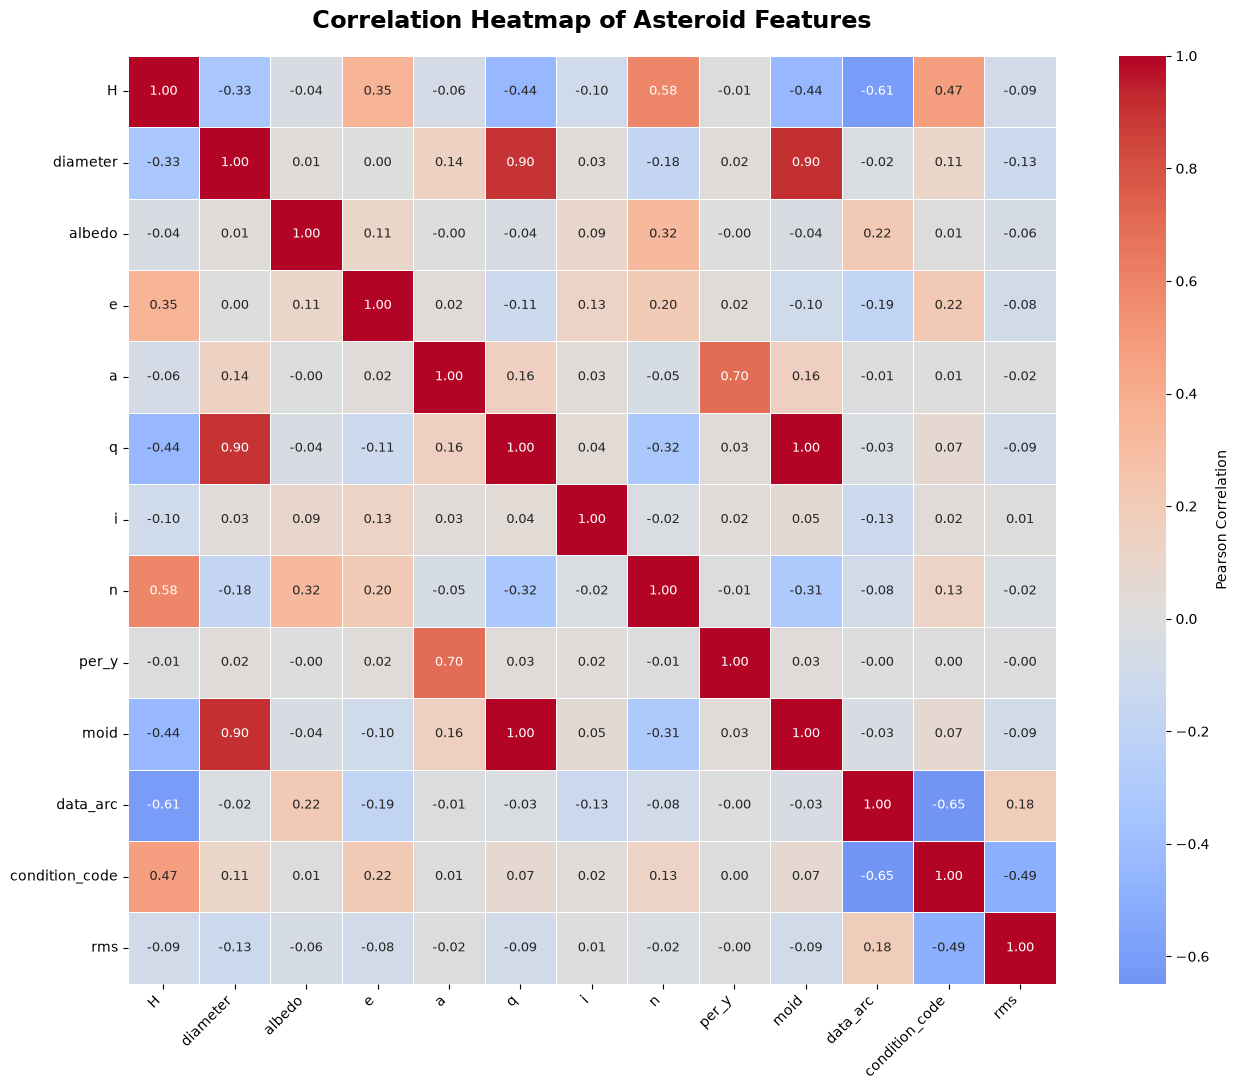


✓ Correlation heatmap created
✓ PNG saved:
  results/correlation_heatmap_all_features.png
✓ SVG saved:
  results/correlation_heatmap_all_features.svg


In [9]:
# ============================================================
# CORRELATION HEATMAP — ALL FEATURES
# DATA PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# 1. Final modelling features
# ------------------------------------------------------------

features = [
    "H",
    "diameter",
    "albedo",
    "e",
    "a",
    "q",
    "i",
    "n",
    "per_y",
    "moid",
    "data_arc",
    "condition_code",
    "rms"
]

# ------------------------------------------------------------
# 2. Use the imputed dataset
# ------------------------------------------------------------

heatmap_data = imputed_data[features].copy()

print("Heatmap dataset shape:", heatmap_data.shape)
print("\nFeatures:")
print(features)

# ------------------------------------------------------------
# 3. Calculate Pearson correlation matrix
# ------------------------------------------------------------

correlation_matrix = heatmap_data.corr(method="pearson")

print("\nCorrelation Matrix:")
display(correlation_matrix.round(3))

# ------------------------------------------------------------
# 4. Create output folder
# ------------------------------------------------------------

Path("results").mkdir(exist_ok=True)

# ------------------------------------------------------------
# 5. Create heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Pearson Correlation"
    },
    annot_kws={
        "fontsize": 9
    }
)

plt.title(
    "Correlation Heatmap of Asteroid Features",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save high-quality PNG
# ------------------------------------------------------------

plt.savefig(
    "results/correlation_heatmap_all_features.png",
    dpi=300,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 7. Save SVG
# ------------------------------------------------------------

plt.savefig(
    "results/correlation_heatmap_all_features.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("\n✓ Correlation heatmap created")
print("✓ PNG saved:")
print("  results/correlation_heatmap_all_features.png")
print("✓ SVG saved:")
print("  results/correlation_heatmap_all_features.svg")

In [48]:
print("NEO value counts before imputation:")
print(imputed_data["neo"].value_counts(dropna=False))

NEO value counts before imputation:
neo
N      1506869
Y        41817
NaN          5
Name: count, dtype: int64


In [49]:
from sklearn.ensemble import RandomForestClassifier

# Make a copy
neo_imputation = imputed_data.copy()

# Predictors for NEO
neo_predictors = [
    "H",
    "diameter",
    "albedo",
    "e",
    "a",
    "q",
    "i",
    "n",
    "per_y",
    "moid",
    "moid_ld",
    "data_arc",
    "condition_code",
    "rms"
]

# Check missing NEO
print(
    "Missing NEO before:",
    neo_imputation["neo"].isna().sum()
)

Missing NEO before: 5


In [50]:
X = neo_imputation[neo_predictors].copy()

# Fill any missing predictor values with their median
for col in neo_predictors:
    X[col] = X[col].fillna(X[col].median())

# Rows where NEO is known
known_mask = neo_imputation["neo"].notna()

# Rows where NEO is missing
missing_mask = neo_imputation["neo"].isna()

X_train = X.loc[known_mask]
y_train = neo_imputation.loc[known_mask, "neo"]

X_missing = X.loc[missing_mask]

print("Training rows:", len(X_train))
print("Rows to impute:", len(X_missing))

Training rows: 1548686
Rows to impute: 5


In [51]:
neo_rf = RandomForestClassifier(
    n_estimators=50,
    random_state=123,
    n_jobs=-1,
    max_features="sqrt"
)

neo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [52]:
neo_predictions = neo_rf.predict(X_missing)

print("Predicted NEO values:")
print(neo_predictions)

Predicted NEO values:
['N' 'Y' 'N' 'N' 'N']


In [53]:
neo_imputation.loc[missing_mask, "neo"] = neo_predictions

In [54]:
imputed_data = neo_imputation

In [55]:
print("NEO values after imputation:")
print(imputed_data["neo"].value_counts(dropna=False))

print("\nMissing NEO after imputation:")
print(imputed_data["neo"].isna().sum())

NEO values after imputation:
neo
N    1506873
Y      41818
Name: count, dtype: int64

Missing NEO after imputation:
0


In [56]:
missing_after = pd.DataFrame({
    "Missing_Count": imputed_data.isna().sum(),
    "Missing_Percentage": imputed_data.isna().mean() * 100
})

print(missing_after)

                Missing_Count  Missing_Percentage
H                           0            0.000000
diameter                    0            0.000000
albedo                      0            0.000000
e                           0            0.000000
a                           0            0.000000
q                           0            0.000000
i                           0            0.000000
n                           0            0.000000
per_y                       0            0.000000
moid                        0            0.000000
moid_ld                     0            0.000000
class                       0            0.000000
data_arc                    0            0.000000
condition_code              0            0.000000
rms                         0            0.000000
neo                         0            0.000000
pha                     29078            1.877586


In [57]:
imputed_data.to_parquet(
    "data/imputed_data.parquet",
    index=False
)

print("Final imputed dataset saved successfully.")

Final imputed dataset saved successfully.


In [59]:
pha_data = imputed_data[
    imputed_data["pha"].notna()
].copy()
print("PHA dataset shape:", pha_data.shape)

PHA dataset shape: (1519613, 17)


In [60]:
print("PHA class counts:")
print(pha_data["pha"].value_counts())

PHA class counts:
pha
N    1517073
Y       2540
Name: count, dtype: int64


In [61]:
print("\nPHA class percentages:")
print(
    pha_data["pha"]
    .value_counts(normalize=True)
    .mul(100)
)


PHA class percentages:
pha
N    99.832852
Y     0.167148
Name: proportion, dtype: float64


In [62]:
print("Missing values in PHA dataset:")
print(pha_data.isna().sum())

Missing values in PHA dataset:
H                 0
diameter          0
albedo            0
e                 0
a                 0
q                 0
i                 0
n                 0
per_y             0
moid              0
moid_ld           0
class             0
data_arc          0
condition_code    0
rms               0
neo               0
pha               0
dtype: int64


In [63]:
pha_data["pha_binary"] = (
    pha_data["pha"]
    .map({"N": 0, "Y": 1})
)

In [64]:
print(pha_data["pha_binary"].value_counts())

pha_binary
0    1517073
1       2540
Name: count, dtype: int64


In [72]:
print("Correlation between MOID and MOID_LD:")
print(
    pha_data[["moid", "moid_ld"]].corr()
)

Dataset loaded successfully.
Total rows: 1548691
Unique spkid: 1548691
Duplicate spkid: 0


In [74]:

# FINAL PREDICTOR SET
# MOID_LD REMOVED DUE TO REDUNDANT INFORMATION


predictors = [
    "H",
    "diameter",
    "albedo",
    "e",
    "a",
    "q",
    "i",
    "n",
    "per_y",
    "moid",
    "data_arc",
    "condition_code",
    "rms"
]

X = pha_data[predictors]
y = pha_data["pha_binary"]

print("Predictors:")
print(predictors)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Predictors:
['H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'n', 'per_y', 'moid', 'data_arc', 'condition_code', 'rms']

X shape: (1519613, 13)
y shape: (1519613,)


In [75]:

# TRAIN / TEST SPLIT
# STRATIFIED BECAUSE OF CLASS IMBALANCE


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training set: (1215690, 13)
Testing set: (303923, 13)

Training classes:
pha_binary
0    1213658
1       2032
Name: count, dtype: int64

Testing classes:
pha_binary
0    303415
1       508
Name: count, dtype: int64


In [76]:

# BASELINE RANDOM FOREST
# NO CLASS WEIGHTING
# NO SMOTE


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

rf_baseline = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight=None
)

print("Training baseline Random Forest...")

rf_baseline.fit(X_train, y_train)

print("Baseline Random Forest training completed.")

# Predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]

# Evaluation
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("\nConfusion Matrix:")
print(cm_baseline)

print("\nBaseline Random Forest Metrics:")
print("Accuracy:",
      accuracy_score(y_test, y_pred_baseline))

print("Precision:",
      precision_score(y_test, y_pred_baseline))

print("Recall:",
      recall_score(y_test, y_pred_baseline))

print("F1 Score:",
      f1_score(y_test, y_pred_baseline))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_baseline))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_baseline))

Training baseline Random Forest...
Baseline Random Forest training completed.

Confusion Matrix:
[[303410      5]
 [     5    503]]

Baseline Random Forest Metrics:
Accuracy: 0.9999670969291564
Precision: 0.9901574803149606
Recall: 0.9901574803149606
F1 Score: 0.9901574803149606
ROC-AUC: 0.9999932007576225
PR-AUC: 0.9983060511991207


In [23]:

# CLASS-WEIGHTED RANDOM FOREST


rf_weighted = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training class-weighted Random Forest...")

rf_weighted.fit(X_train, y_train)

print("Class-weighted Random Forest training completed.")

# Predictions
y_pred_weighted = rf_weighted.predict(X_test)
y_prob_weighted = rf_weighted.predict_proba(X_test)[:, 1]

# Evaluation
cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted
)

print("\nConfusion Matrix:")
print(cm_weighted)

print("\nClass-Weighted Random Forest Metrics:")

print("Accuracy:",
      accuracy_score(y_test, y_pred_weighted))

print("Precision:",
      precision_score(y_test, y_pred_weighted))

print("Recall:",
      recall_score(y_test, y_pred_weighted))

print("F1 Score:",
      f1_score(y_test, y_pred_weighted))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_weighted))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_weighted))

Training class-weighted Random Forest...
Class-weighted Random Forest training completed.

Confusion Matrix:
[[303404     11]
 [     3    505]]

Class-Weighted Random Forest Metrics:
Accuracy: 0.9999539357008189
Precision: 0.9786821705426356
Recall: 0.9940944881889764
F1 Score: 0.986328125
ROC-AUC: 0.9999984364337662
PR-AUC: 0.999097197904001


In [12]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [24]:
# ============================================================
# RANDOM FOREST + 10% SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Apply 10% SMOTE ONLY to training data
smote_10 = SMOTE(
    sampling_strategy=0.10,
    random_state=123
)

X_train_smote_10, y_train_smote_10 = smote_10.fit_resample(
    X_train,
    y_train
)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER 10% SMOTE:")
print(y_train_smote_10.value_counts())

print("\nOriginal training shape:")
print(X_train.shape)

print("10% SMOTE training shape:")
print(X_train_smote_10.shape)


# Train Random Forest
rf_smote_10 = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight=None
)

print("\nTraining Random Forest + 10% SMOTE...")

rf_smote_10.fit(
    X_train_smote_10,
    y_train_smote_10
)

print("10% SMOTE Random Forest training completed.")


# Predictions on ORIGINAL test set
y_pred_smote_10 = rf_smote_10.predict(X_test)

y_prob_smote_10 = rf_smote_10.predict_proba(
    X_test
)[:, 1]


# Confusion matrix
cm_smote_10 = confusion_matrix(
    y_test,
    y_pred_smote_10
)

print("\n10% SMOTE Confusion Matrix:")
print(cm_smote_10)


# Metrics
print("\n10% SMOTE Random Forest Metrics")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_smote_10)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_smote_10)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_smote_10)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_smote_10)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_smote_10)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_smote_10
    )
)

Class distribution BEFORE SMOTE:
pha_binary
0    1213658
1       2032
Name: count, dtype: int64

Class distribution AFTER 10% SMOTE:
pha_binary
0    1213658
1     121365
Name: count, dtype: int64

Original training shape:
(1215690, 13)
10% SMOTE training shape:
(1335023, 13)

Training Random Forest + 10% SMOTE...
10% SMOTE Random Forest training completed.

10% SMOTE Confusion Matrix:
[[303406      9]
 [     5    503]]

10% SMOTE Random Forest Metrics
--------------------------------
Accuracy: 0.9999539357008189
Precision: 0.982421875
Recall: 0.9901574803149606
F1 Score: 0.9862745098039216
ROC-AUC: 0.9999987900203212
PR-AUC: 0.9992912758763131


In [25]:
# ============================================================
# RANDOM FOREST + 20% SMOTE
# ============================================================

smote_20 = SMOTE(
    sampling_strategy=0.20,
    random_state=123
)

X_train_smote_20, y_train_smote_20 = smote_20.fit_resample(
    X_train,
    y_train
)

print("Class distribution AFTER 20% SMOTE:")
print(y_train_smote_20.value_counts())

print("\n20% SMOTE training shape:")
print(X_train_smote_20.shape)


# Train Random Forest
rf_smote_20 = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight=None
)

print("\nTraining Random Forest + 20% SMOTE...")

rf_smote_20.fit(
    X_train_smote_20,
    y_train_smote_20
)

print("20% SMOTE Random Forest training completed.")


# Predictions on ORIGINAL test set
y_pred_smote_20 = rf_smote_20.predict(X_test)

y_prob_smote_20 = rf_smote_20.predict_proba(
    X_test
)[:, 1]


# Confusion matrix
cm_smote_20 = confusion_matrix(
    y_test,
    y_pred_smote_20
)

print("\n20% SMOTE Confusion Matrix:")
print(cm_smote_20)


# Metrics
print("\n20% SMOTE Random Forest Metrics")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_smote_20)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_smote_20)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_smote_20)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_smote_20)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_smote_20)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_smote_20
    )
)

Class distribution AFTER 20% SMOTE:
pha_binary
0    1213658
1     242731
Name: count, dtype: int64

20% SMOTE training shape:
(1456389, 13)

Training Random Forest + 20% SMOTE...
20% SMOTE Random Forest training completed.

20% SMOTE Confusion Matrix:
[[303404     11]
 [     5    503]]

20% SMOTE Random Forest Metrics
--------------------------------
Accuracy: 0.9999473550866502
Precision: 0.9785992217898832
Recall: 0.9901574803149606
F1 Score: 0.9843444227005871
ROC-AUC: 0.9999987283859676
PR-AUC: 0.9992562012283704


In [26]:
print(y_prob_baseline.shape)
print(y_prob_weighted.shape)
print(y_prob_smote_10.shape)
print(y_prob_smote_20.shape)


(303923,)
(303923,)
(303923,)
(303923,)


In [ ]:
# ============================================================
# RANDOM SEED STABILITY TESTS
# SELECTED MODEL: CLASS-WEIGHTED RANDOM FOREST
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import pandas as pd

# Random seeds to test
seeds = [1, 10, 42, 100, 999]

# Store results
results = []

for seed in seeds:

    # --------------------------------------------------------
    # 1. Create a new stratified 80/20 train-test split
    # --------------------------------------------------------
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y
    )

    # --------------------------------------------------------
    # 2. Train the selected Class-Weighted Random Forest
    # --------------------------------------------------------
    rf_s = RandomForestClassifier(
        n_estimators=500,
        max_features=4,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    rf_s.fit(X_train_s, y_train_s)

    # --------------------------------------------------------
    # 3. Generate predictions
    # --------------------------------------------------------
    y_pred_s = rf_s.predict(X_test_s)
    y_prob_s = rf_s.predict_proba(X_test_s)[:, 1]

    # --------------------------------------------------------
    # 4. Calculate evaluation metrics
    # --------------------------------------------------------
    recall_s = recall_score(y_test_s, y_pred_s)
    precision_s = precision_score(y_test_s, y_pred_s)
    f1_s = f1_score(y_test_s, y_pred_s)
    pr_auc_s = average_precision_score(y_test_s, y_prob_s)

    # --------------------------------------------------------
    # 5. Store results
    # --------------------------------------------------------
    results.append([
        seed,
        recall_s,
        precision_s,
        f1_s,
        pr_auc_s
    ])

# ------------------------------------------------------------
# 6. Create results table
# ------------------------------------------------------------
results_df = pd.DataFrame(
    results,
    columns=[
        "Seed",
        "Recall",
        "Precision",
        "F1",
        "PR-AUC"
    ]
)

# Display results
print(results_df.to_string(index=False))

In [28]:
# BASELINE RANDOM FOREST
rf_baseline = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight=None
)

rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
y_prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]


In [29]:
print("SMOTE 10% Metrics")
print("------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_smote_10))
print("Precision:", precision_score(y_test, y_pred_smote_10))
print("Recall:", recall_score(y_test, y_pred_smote_10))
print("F1 Score:", f1_score(y_test, y_pred_smote_10))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote_10))
print("PR-AUC:", average_precision_score(y_test, y_prob_smote_10))

print("\nSMOTE 20% Metrics")
print("------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_smote_20))
print("Precision:", precision_score(y_test, y_pred_smote_20))
print("Recall:", recall_score(y_test, y_pred_smote_20))
print("F1 Score:", f1_score(y_test, y_pred_smote_20))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote_20))
print("PR-AUC:", average_precision_score(y_test, y_prob_smote_20))


SMOTE 10% Metrics
------------------
Accuracy: 0.9999539357008189
Precision: 0.982421875
Recall: 0.9901574803149606
F1 Score: 0.9862745098039216
ROC-AUC: 0.9999987900203212
PR-AUC: 0.9992912758763131

SMOTE 20% Metrics
------------------
Accuracy: 0.9999473550866502
Precision: 0.9785992217898832
Recall: 0.9901574803149606
F1 Score: 0.9843444227005871
ROC-AUC: 0.9999987283859676
PR-AUC: 0.9992562012283704


In [30]:
import pandas as pd

# Create a dictionary with your results
results = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "SMOTE 10%": [
        0.9999539357008189,
        0.982421875,
        0.9901574803149606,
        0.9862745098039216,
        0.9999987900203212,
        0.9992912758763131
    ],
    "SMOTE 20%": [
        0.9999473550866502,
        0.9785992217898832,
        0.9901574803149606,
        0.9843444227005871,
        0.9999987283859676,
        0.9992562012283704
    ]
}

# Convert to DataFrame
smote_results_df = pd.DataFrame(results)

# Display the table
print(smote_results_df)


      Metric  SMOTE 10%  SMOTE 20%
0   Accuracy   0.999954   0.999947
1  Precision   0.982422   0.978599
2     Recall   0.990157   0.990157
3   F1 Score   0.986275   0.984344
4    ROC-AUC   0.999999   0.999999
5     PR-AUC   0.999291   0.999256


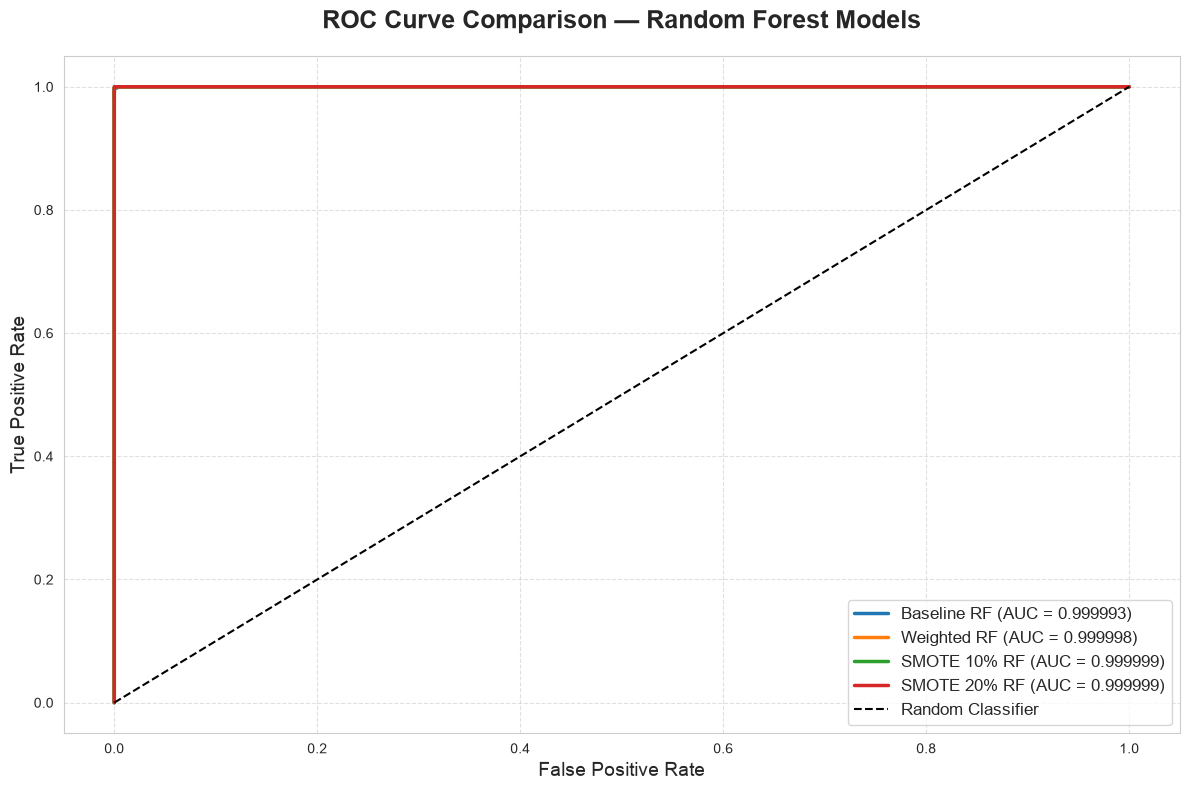

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

# Use a clean aesthetic style
sns.set_style("whitegrid")

# Compute ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_baseline)
fpr_weight, tpr_weight, _ = roc_curve(y_test, y_prob_weighted)
fpr_sm10, tpr_sm10, _ = roc_curve(y_test, y_prob_smote_10)
fpr_sm20, tpr_sm20, _ = roc_curve(y_test, y_prob_smote_20)

# Compute AUC values
auc_base = roc_auc_score(y_test, y_prob_baseline)
auc_weight = roc_auc_score(y_test, y_prob_weighted)
auc_sm10 = roc_auc_score(y_test, y_prob_smote_10)
auc_sm20 = roc_auc_score(y_test, y_prob_smote_20)

# Plot ROC curves
plt.figure(figsize=(12, 8))

plt.plot(fpr_base, tpr_base, linewidth=2.5,
         label=f"Baseline RF (AUC = {auc_base:.6f})", color="#1f77b4")

plt.plot(fpr_weight, tpr_weight, linewidth=2.5,
         label=f"Weighted RF (AUC = {auc_weight:.6f})", color="#ff7f0e")

plt.plot(fpr_sm10, tpr_sm10, linewidth=2.5,
         label=f"SMOTE 10% RF (AUC = {auc_sm10:.6f})", color="#2ca02c")

plt.plot(fpr_sm20, tpr_sm20, linewidth=2.5,
         label=f"SMOTE 20% RF (AUC = {auc_sm20:.6f})", color="#d62728")

# Random classifier line
plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")

# Labels and title
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve Comparison — Random Forest Models", fontsize=18, fontweight="bold", pad=20)

# Legend
plt.legend(fontsize=12, loc="lower right", frameon=True)

# Grid and layout
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()


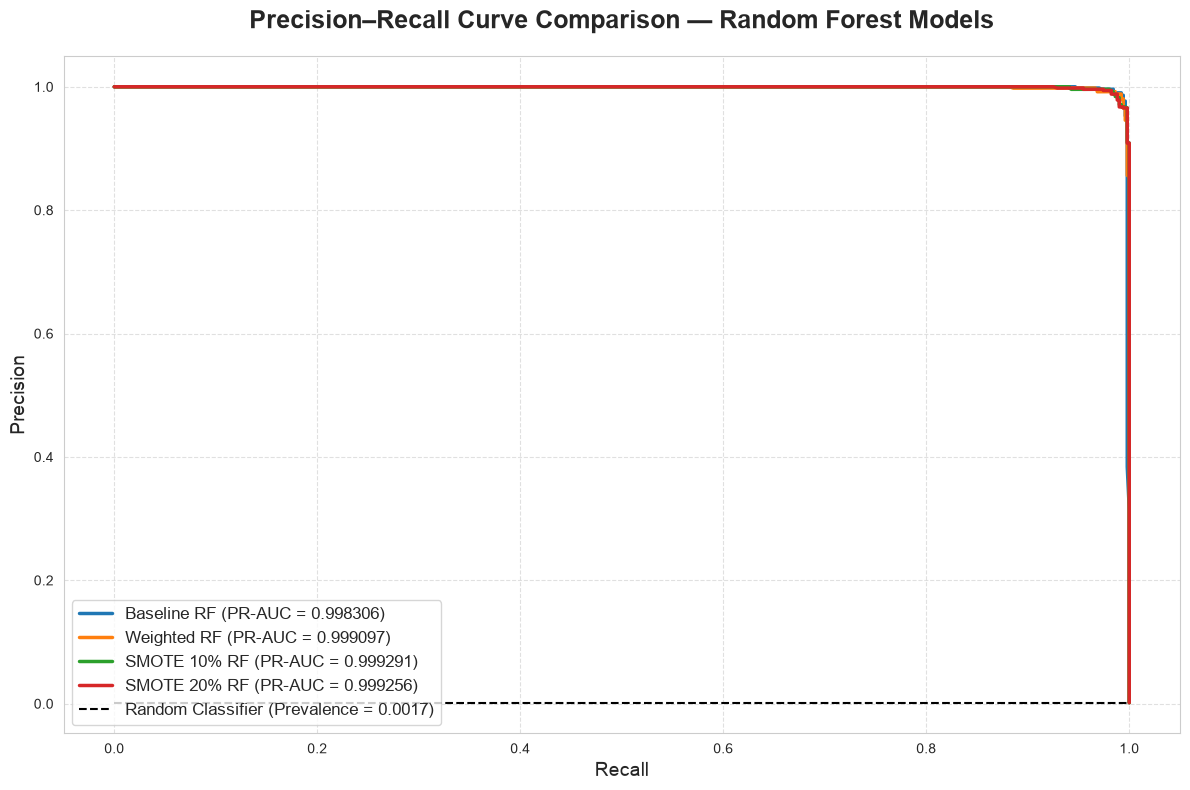

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns

# Use a clean aesthetic style
sns.set_style("whitegrid")

# Compute PR curves
prec_base, rec_base, _ = precision_recall_curve(y_test, y_prob_baseline)
prec_weight, rec_weight, _ = precision_recall_curve(y_test, y_prob_weighted)
prec_sm10, rec_sm10, _ = precision_recall_curve(y_test, y_prob_smote_10)
prec_sm20, rec_sm20, _ = precision_recall_curve(y_test, y_prob_smote_20)

# Compute PR-AUC values
auc_base = average_precision_score(y_test, y_prob_baseline)
auc_weight = average_precision_score(y_test, y_prob_weighted)
auc_sm10 = average_precision_score(y_test, y_prob_smote_10)
auc_sm20 = average_precision_score(y_test, y_prob_smote_20)

# Plot PR curves
plt.figure(figsize=(12, 8))

plt.plot(rec_base, prec_base, linewidth=2.5,
         label=f"Baseline RF (PR-AUC = {auc_base:.6f})", color="#1f77b4")

plt.plot(rec_weight, prec_weight, linewidth=2.5,
         label=f"Weighted RF (PR-AUC = {auc_weight:.6f})", color="#ff7f0e")

plt.plot(rec_sm10, prec_sm10, linewidth=2.5,
         label=f"SMOTE 10% RF (PR-AUC = {auc_sm10:.6f})", color="#2ca02c")

plt.plot(rec_sm20, prec_sm20, linewidth=2.5,
         label=f"SMOTE 20% RF (PR-AUC = {auc_sm20:.6f})", color="#d62728")

# Baseline classifier line (horizontal line at positive class prevalence)
positive_rate = y_test.mean()
plt.hlines(positive_rate, xmin=0, xmax=1, colors="k", linestyles="--",
           linewidth=1.5, label=f"Random Classifier (Prevalence = {positive_rate:.4f})")

# Labels and title
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("Precision–Recall Curve Comparison — Random Forest Models",
          fontsize=18, fontweight="bold", pad=20)

# Legend
plt.legend(fontsize=12, loc="lower left", frameon=True)

# Grid and layout
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()


In [38]:
# BASELINE CONFUSION MATRIX
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

# WEIGHTED CONFUSION MATRIX
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

# SMOTE 10% CONFUSION MATRIX
cm_smote_10 = confusion_matrix(y_test, y_pred_smote_10)

# SMOTE 20% CONFUSION MATRIX
cm_smote_20 = confusion_matrix(y_test, y_pred_smote_20)


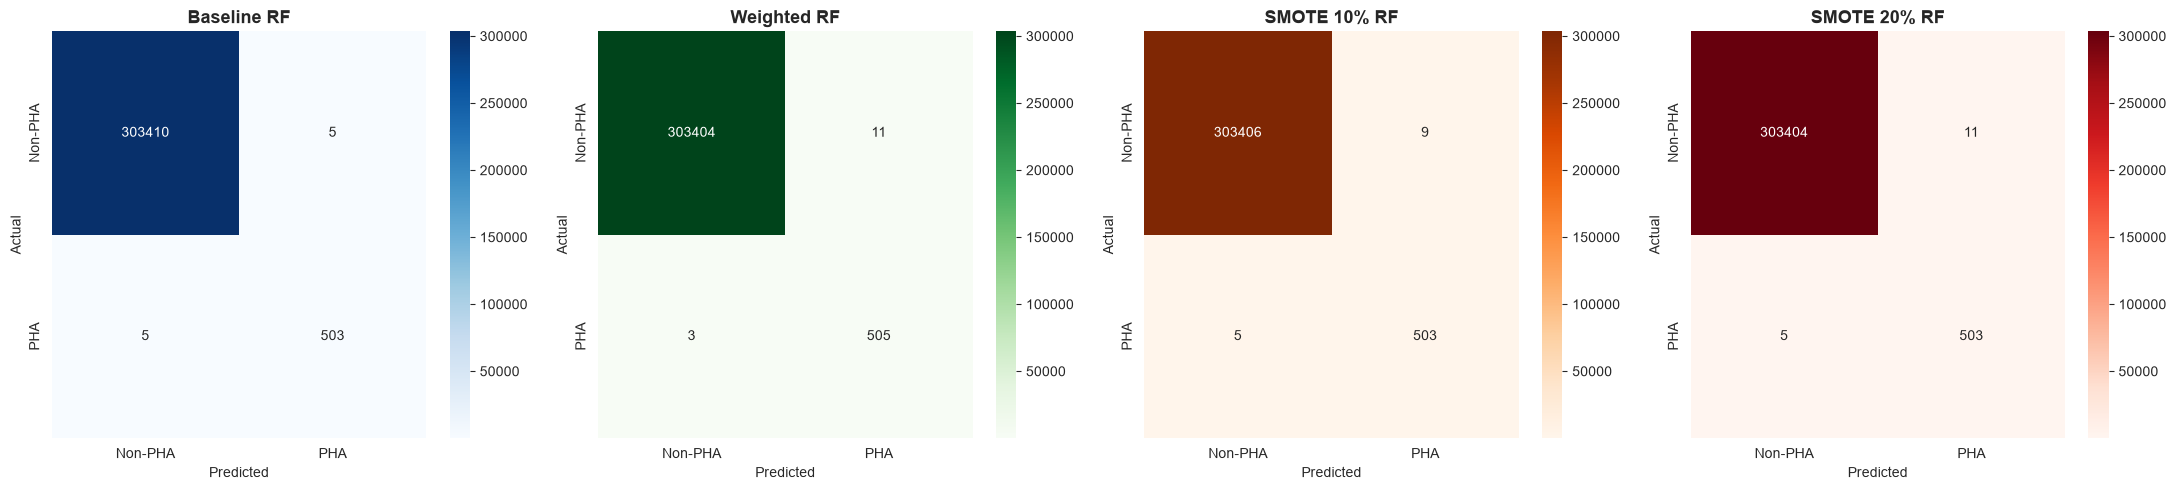

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# --- Baseline RF ---
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Non-PHA", "PHA"],
    yticklabels=["Non-PHA", "PHA"]
)
axes[0].set_title("Baseline RF", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# --- Weighted RF ---
sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["Non-PHA", "PHA"],
    yticklabels=["Non-PHA", "PHA"]
)
axes[1].set_title("Weighted RF", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# --- SMOTE 10% RF ---
sns.heatmap(
    cm_smote_10,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[2],
    xticklabels=["Non-PHA", "PHA"],
    yticklabels=["Non-PHA", "PHA"]
)
axes[2].set_title("SMOTE 10% RF", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

# --- SMOTE 20% RF ---
sns.heatmap(
    cm_smote_20,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=axes[3],
    xticklabels=["Non-PHA", "PHA"],
    yticklabels=["Non-PHA", "PHA"]
)
axes[3].set_title("SMOTE 20% RF", fontsize=13, fontweight="bold")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [44]:
results = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Class-Weighted Random Forest",
        "RF + SMOTE 10%",
        "RF + SMOTE 20%"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_smote_10),
        accuracy_score(y_test, y_pred_smote_20)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_smote_10),
        precision_score(y_test, y_pred_smote_20)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_smote_10),
        recall_score(y_test, y_pred_smote_20)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_smote_10),
        f1_score(y_test, y_pred_smote_20)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_baseline),
        roc_auc_score(y_test, y_prob_weighted),
        roc_auc_score(y_test, y_prob_smote_10),
        roc_auc_score(y_test, y_prob_smote_20)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_baseline),
        average_precision_score(y_test, y_prob_weighted),
        average_precision_score(y_test, y_prob_smote_10),
        average_precision_score(y_test, y_prob_smote_20)
    ]
})

results = results.round(6)
display(results.style.hide(axis="index"))


Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Baseline Random Forest,0.999967,0.990157,0.990157,0.990157,0.999993,0.998306
Class-Weighted Random Forest,0.999954,0.978682,0.994094,0.986328,0.999998,0.999097
RF + SMOTE 10%,0.999954,0.982422,0.990157,0.986275,0.999999,0.999291
RF + SMOTE 20%,0.999947,0.978599,0.990157,0.984344,0.999999,0.999256


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Model performance results
results = pd.DataFrame({
    "Model": [
        "Baseline RF",
        "Weighted RF",
        "SMOTE 10%",
        "SMOTE 20%"
    ],
    "Precision": [
        0.990157,
        0.978682,
        0.982422,
        0.978599
    ],
    "Recall": [
        0.990157,
        0.994094,
        0.990157,
        0.990157
    ],
    "F1 Score": [
        0.990157,
        0.986328,
        0.986275,
        0.984344
    ],
    "PR-AUC": [
        0.998306,
        0.999097,
        0.999291,
        0.999256
    ]
})

# Set positions
x = np.arange(len(results["Model"]))
width = 0.20

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars
ax.bar(x - 1.5*width, results["Precision"], width, label="Precision")
ax.bar(x - 0.5*width, results["Recall"], width, label="Recall")
ax.bar(x + 0.5*width, results["F1 Score"], width, label="F1 Score")
ax.bar(x + 1.5*width, results["PR-AUC"], width, label="PR-AUC")

# Labels
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Comparison of Random Forest Models",
    fontsize=15,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(results["Model"], fontsize=11)

# Zoomed y-axis to show small differences
ax.set_ylim(0.97, 1.00)

# Add horizontal grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add legend
ax.legend(loc="lower left", fontsize=10)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

# Save high-resolution versions for dissertation
plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "model_performance_comparison.svg",
    bbox_inches="tight"
)

plt.show()

Starting SHAP analysis...
Model trained. Computing SHAP values...


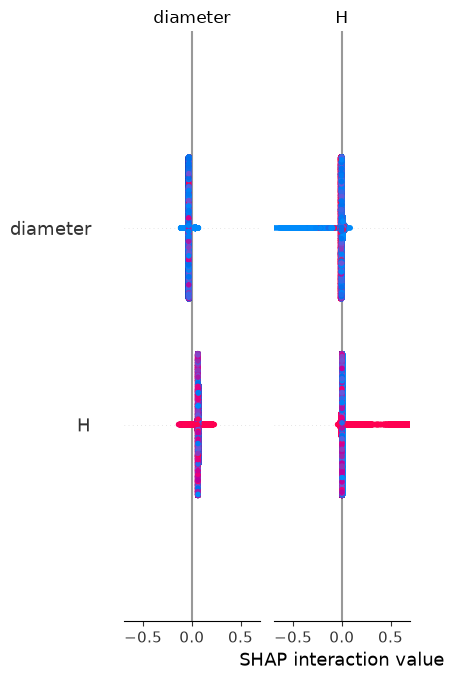

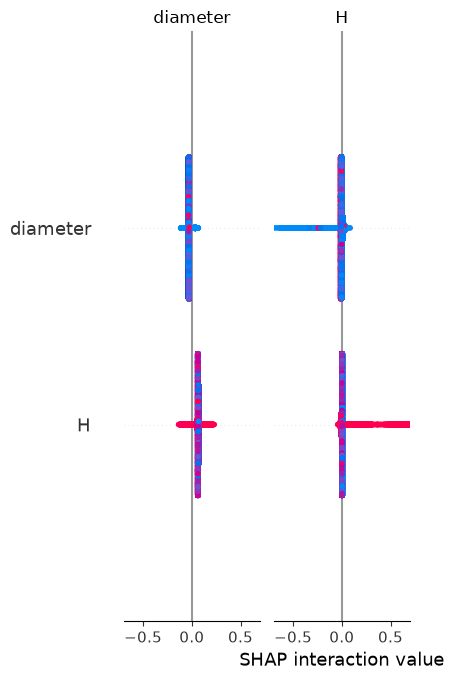

SHAP analysis complete.


In [33]:
# ============================================================
# SHAP ANALYSIS — FIXED VERSION
# ============================================================

import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Starting SHAP analysis...")

# ------------------------------------------------------------
# 1. Load final imputed dataset
# ------------------------------------------------------------
imputed_data = pd.read_parquet("data/imputed_data.parquet")

pha_data = imputed_data[imputed_data["pha"].notna()].copy()
pha_data["pha_binary"] = pha_data["pha"].map({"N": 0, "Y": 1})

# ------------------------------------------------------------
# 2. Define predictors
# ------------------------------------------------------------
predictors = [
    "H", "diameter", "albedo", "e", "a", "q", "i", "n",
    "per_y", "moid", "data_arc", "condition_code", "rms"
]

X = pha_data[predictors]
y = pha_data["pha_binary"]

# ------------------------------------------------------------
# 3. Train/test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

# ------------------------------------------------------------
# 4. Train final model (class-weighted RF)
# ------------------------------------------------------------
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features=4,
    random_state=123,
    n_jobs=-1,
    class_weight="balanced"
)

rf_final.fit(X_train, y_train)

print("Model trained. Computing SHAP values...")

# ------------------------------------------------------------
# 5. SHAP Explainer
# ------------------------------------------------------------
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test)

# ------------------------------------------------------------
# 6. Summary plot (global feature importance)
# ------------------------------------------------------------
shap.summary_plot(shap_values, X_test, plot_type="bar")

# ------------------------------------------------------------
# 7. Beeswarm plot
# ------------------------------------------------------------
shap.summary_plot(shap_values, X_test)

print("SHAP analysis complete.")


In [65]:
# Extract SHAP values for the PHA class (class 1)
shap_matrix = shap_values[:, :, 1]

print("SHAP matrix shape:", shap_matrix.shape)
print("X_test shape:", X_test.shape)

SHAP matrix shape: (303923, 13)
X_test shape: (303923, 13)


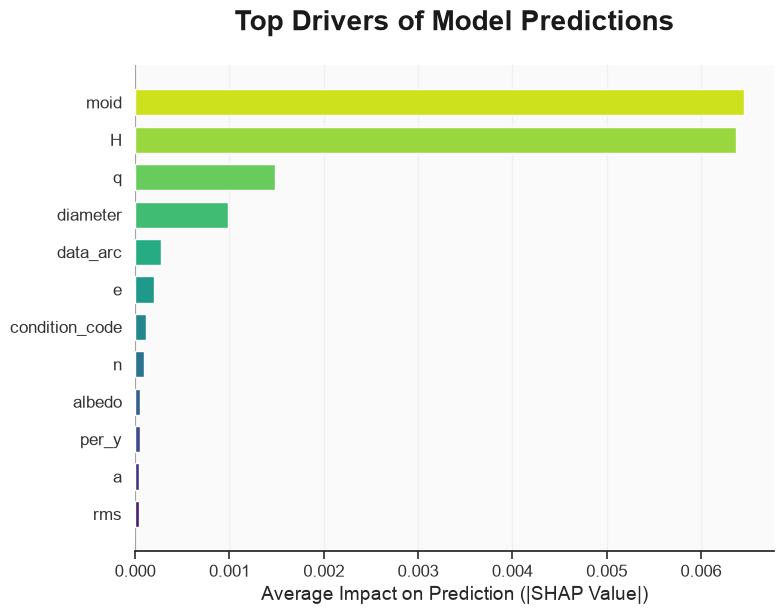

In [70]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig = plt.figure(figsize=(12, 8), facecolor="white")

shap.summary_plot(
    shap_matrix,
    X_test,
    plot_type="bar",
    max_display=12,
    show=False
)

ax = plt.gca()

# Custom color palette
colors = sns.color_palette("viridis", len(ax.patches))
# Alternatives:
# sns.color_palette("Spectral", len(ax.patches))
# sns.color_palette("Set2", len(ax.patches))
# sns.color_palette("flare", len(ax.patches))
# sns.color_palette("crest", len(ax.patches))

for bar, color in zip(ax.patches, colors):
    bar.set_facecolor(color)

ax.set_title(
    "Top Drivers of Model Predictions",
    fontsize=20,
    fontweight="bold",
    color="#1a1a1a",
    pad=25
)

ax.set_xlabel(
    "Average Impact on Prediction (|SHAP Value|)",
    fontsize=14
)

ax.tick_params(axis="both", labelsize=12)

# Subtle background
ax.set_facecolor("#FAFAFA")

# Clean look
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

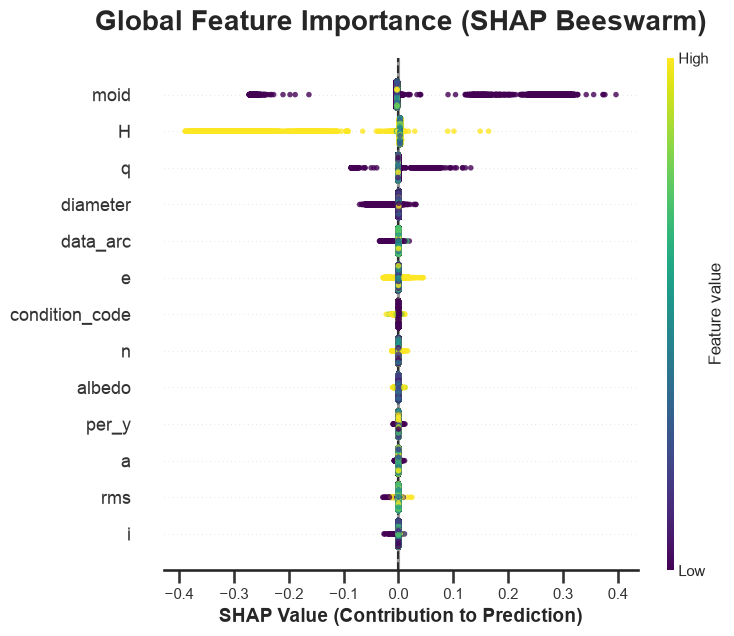

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_theme(style="white", context="talk")

plt.figure(figsize=(14, 9))

shap.summary_plot(
    shap_matrix,
    X_test,
    max_display=15,
    cmap="viridis",
    alpha=0.8,
    show=False
)

ax = plt.gca()

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Emphasize x=0 line
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.title(
    "Global Feature Importance (SHAP Beeswarm)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "SHAP Value (Contribution to Prediction)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
